In [1]:
import sys
import os
import numpy as np
import torch
from torch.utils.data import DataLoader, Subset
from sklearn.model_selection import train_test_split
from scipy.stats import pearsonr

In [2]:
project_root = os.path.abspath("..")
if project_root not in sys.path:
    sys.path.insert(0, project_root)

In [3]:
from kszcnn.simplified_model_comparison_err import *

In [4]:
np.random.seed(SEED)
torch.manual_seed(SEED)

In [5]:
print(f"\nTrain realization: {TRAIN_REAL_IDX}")
print(f"Test realization:  {TEST_REAL_IDX}")


Train realization: 0
Test realization:  14


In [6]:
results = []
all_results = {}

for i, mode in enumerate(INPUT_MODES):

    (rms_true, rms_lin, rms_cnn,
     rmse_lin, rmse_cnn,
     p68_lin, p95_lin,
     p68_cnn, p95_cnn, p99_cnn,
     true, vlin, preds) = run_experiment(
        mode, TRAIN_REAL_IDX, TEST_REAL_IDX
    )

    if i == 0:
        print("\n===== Linear Baseline =====")
        print(f"RMS(true) = {rms_true:.3f}")
        print(f"RMS(pred) = {rms_lin:.3f}")
        print(f"RMSE      = {rmse_lin:.3f}")
        print(f"p68       = {p68_lin:.3f}")
        print(f"p95       = {p95_lin:.3f}")

    results.append({
        "Model": mode,
        "RMS_CNN": rms_cnn,
        "RMSE_CNN": rmse_cnn,
        "p68_cnn": p68_cnn,
        "p95_cnn": p95_cnn,
        "p99_cnn": p99_cnn
    })

    all_results[mode] = {
        "true": true,
        "pred": preds
    }


Running model: density
Selected halos: 547
Selected halos: 569
Epoch 1: Train=3.093e-01 | Val=4.906e-01
Epoch 2: Train=2.345e-01 | Val=4.249e-01
Epoch 3: Train=2.068e-01 | Val=3.853e-01
Epoch 4: Train=2.003e-01 | Val=4.208e-01
Epoch 5: Train=2.017e-01 | Val=4.063e-01
Epoch 6: Train=1.954e-01 | Val=3.553e-01
Epoch 7: Train=1.945e-01 | Val=4.476e-01
Epoch 8: Train=1.881e-01 | Val=3.437e-01
Epoch 9: Train=1.824e-01 | Val=3.658e-01
Epoch 10: Train=1.804e-01 | Val=3.254e-01
Epoch 11: Train=1.891e-01 | Val=3.498e-01
Epoch 12: Train=1.744e-01 | Val=3.612e-01
Epoch 13: Train=1.723e-01 | Val=3.307e-01
Epoch 14: Train=1.708e-01 | Val=4.112e-01
Epoch 15: Train=1.909e-01 | Val=3.642e-01
Epoch 16: Train=1.696e-01 | Val=4.228e-01
Epoch 17: Train=1.708e-01 | Val=3.498e-01
Epoch 18: Train=1.688e-01 | Val=2.912e-01
Epoch 19: Train=1.557e-01 | Val=2.857e-01
Epoch 20: Train=1.540e-01 | Val=3.049e-01
Epoch 21: Train=1.553e-01 | Val=2.818e-01
Epoch 22: Train=1.506e-01 | Val=2.648e-01
Epoch 23: Train=1.558

In [7]:
import pandas as pd

df = pd.DataFrame(results)
print(df)

              Model     RMS_CNN   RMSE_CNN    p68_cnn     p95_cnn     p99_cnn
0           density  107.163193  54.098583  38.450142  100.988190  216.049362
1       density_pos  103.252655  54.794697  36.734798  116.706093  214.211349
2  density_pos_mass   99.138702  50.994682  29.871696  103.715881  205.876663
3          pos_mass   94.442528  67.438606  44.986851  133.626740  295.606079
4               pos   96.034988  64.883888  48.157223  132.541565  242.766357


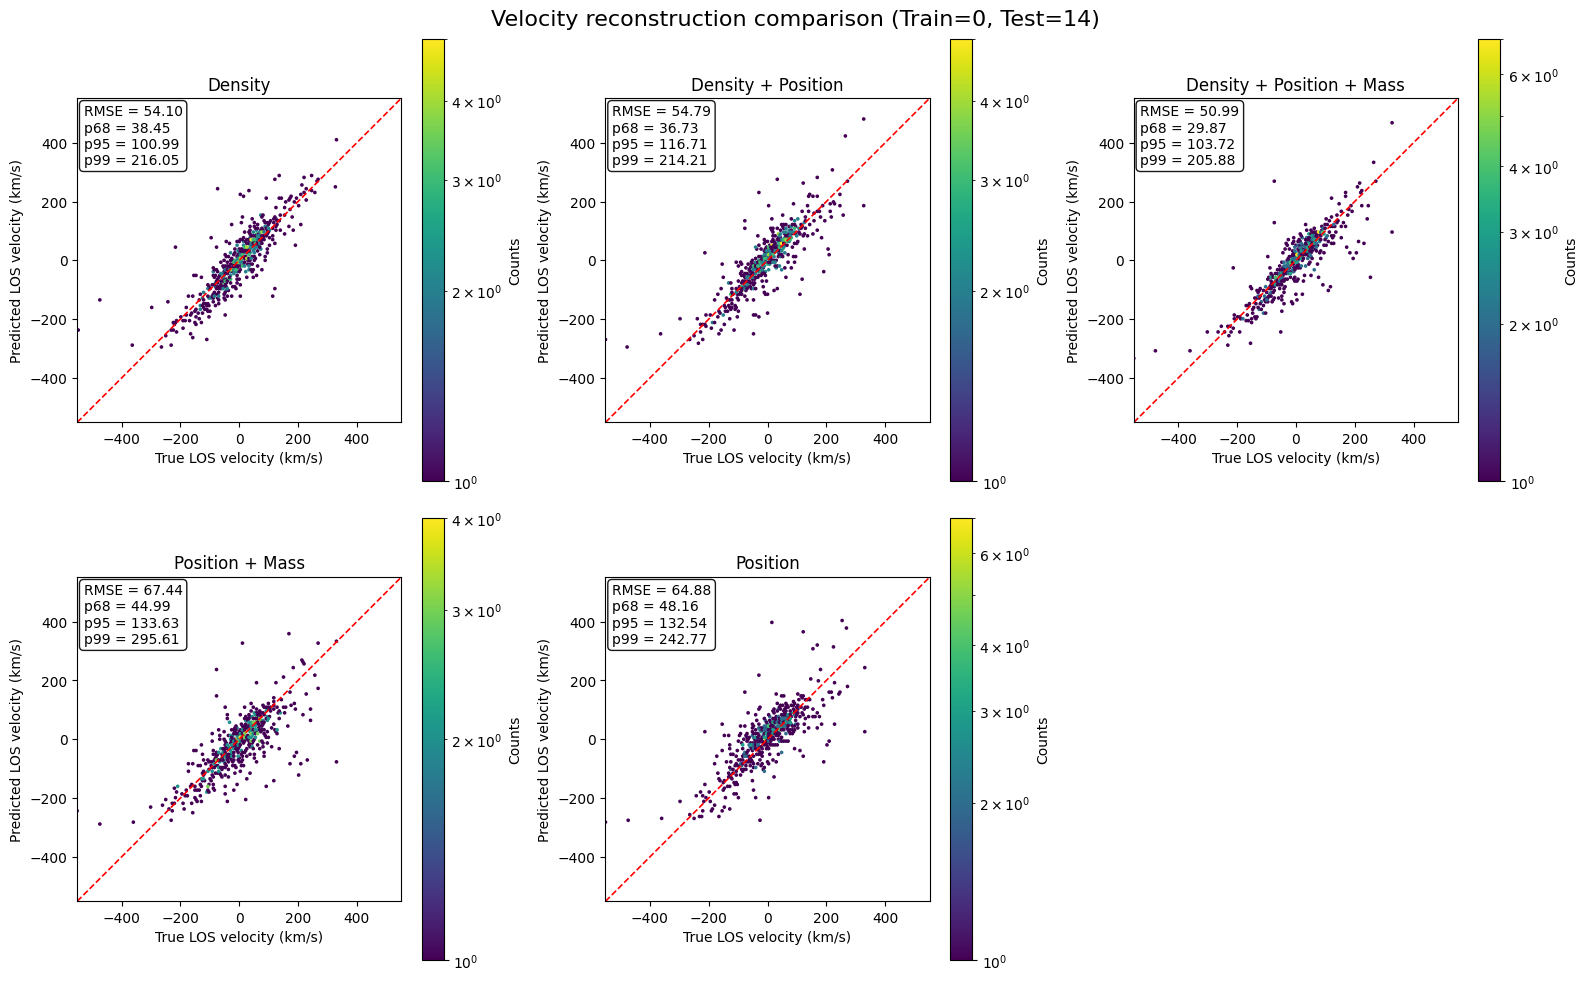

In [8]:
#  comparison plots

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

#  global limits
global_max = 0
for mode in all_results:
    t = all_results[mode]["true"]
    p = all_results[mode]["pred"]
    global_max = max(global_max, np.max(np.abs(t)), np.max(np.abs(p)))

lims = [-global_max, global_max]

#  plotting 
for i, mode in enumerate(INPUT_MODES):

    true = all_results[mode]["true"]
    preds = all_results[mode]["pred"]

    hb = hexbin_panel(
        axes[i],
        true,
        preds,
        title=MODEL_TITLES[mode],
        lims=lims
    )

    cb = fig.colorbar(hb, ax=axes[i])
    cb.set_label("Counts")

# remove unused panel
fig.delaxes(axes[-1])

plt.suptitle(
    f"Velocity reconstruction comparison (Train={TRAIN_REAL_IDX}, Test={TEST_REAL_IDX})",
    fontsize=16
)

plt.tight_layout()
plt.savefig("velocity_recons_comparison.png")
plt.show()

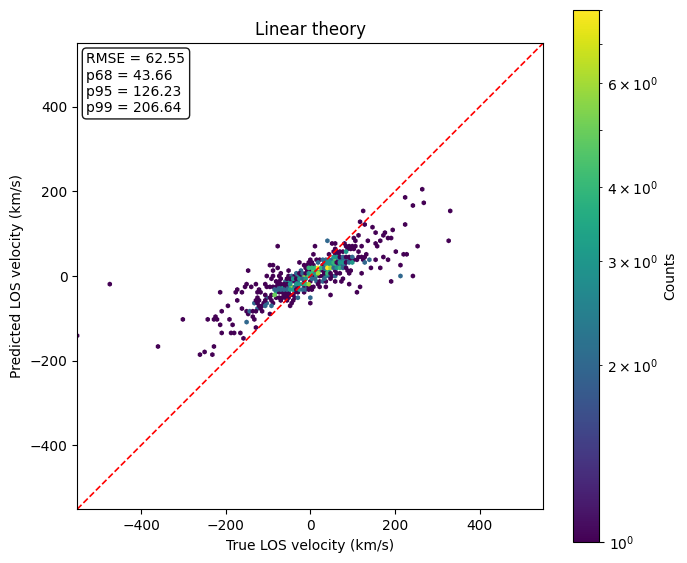

In [9]:
fig, ax = plt.subplots(figsize=(7, 6))

# global limits
vmax = max(np.max(np.abs(true)), np.max(np.abs(vlin)))
lims = [-vmax, vmax]

# hexbin 
hb = hexbin_panel(
    ax,
    true,
    vlin,
    title="Linear theory",
    lims=lims
)

#  colorbar 
cb = fig.colorbar(hb, ax=ax)
cb.set_label("Counts")

plt.tight_layout()
plt.savefig("velocity_recons_vlin_true_comp.png")
plt.show()